# Treinamento e Exportação de Modelo YOLOv8 para ONNX

Este notebook realiza o pipeline completo de:

1. Instalação de dependências
2. Download do dataset
3. Treinamento/fine-tuning do YOLOv8n (com opção de subir para YOLOv8s/YOLOv8m)
4. Validação com inferências em imagens de teste
5. Visualização das detecções (bounding boxes + labels + confiança)
6. Exportação para ONNX
7. Confirmação do arquivo ONNX gerado

> própria VM do Colab (`/content/...`). Ao final, o arquivo `.onnx` fica disponível na
> aba **Arquivos** (ícone de pasta 📁 na barra lateral esquerda do Colab), dentro de
> `/content/output_model/`, para você baixar manualmente com clique direito → **Fazer
> download**.
>
> ⚠️ **Importante:** como o armazenamento é efêmero, tudo é apagado quando a sessão do
> Colab reinicia ou expira. Baixe o `.onnx` antes de encerrar a sessão.
>
> **Dataset usado neste notebook:** por padrão, usamos o **COCO128** (subconjunto oficial
> do COCO, 128 imagens, 80 classes), pois é baixado automaticamente pela Ultralytics e
> permite treinar rapidamente no Colab. Se você tiver um dataset customizado (formato
> YOLO, com `data.yaml`), envie-o para `/content/` (aba Arquivos → upload, ou
> descompactando um `.zip`) e troque a variável `DATASET_YAML` na Célula 2 pelo caminho
> dele — todo o resto do notebook funciona sem alterações.
>
> **Ambiente recomendado:** Colab com GPU (Menu → Ambiente de execução → Alterar tipo de
> ambiente de execução → GPU, preferencialmente T4 ou superior).

## 1. Instalação das dependências

In [1]:
# Instala as bibliotecas necessárias.
# ultralytics: framework YOLOv8 (treino, val, export)
# onnx e onnxruntime: para validar o modelo exportado
# opencv-python-headless: manipulação de imagens/vídeo sem GUI (compatível com Colab)
!pip install -q ultralytics onnx onnxruntime onnxsim opencv-python-headless

print("✅ Dependências instaladas com sucesso.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 49.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 57.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.2/343.2 kB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.7/88.7 kB 5.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.36.2 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 7.36.2 which is incompatible.


In [2]:
import os
import time
import random
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

import ultralytics
from ultralytics import YOLO

print(f"Ultralytics versão: {ultralytics.__version__}")
ultralytics.checks()  # Mostra info de ambiente: Python, PyTorch, GPU disponível, etc.


Ultralytics 8.4.160 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.6/112.6 GB disk)


## 2. Configurações gerais

Ajuste estas variáveis conforme sua necessidade. Se quiser usar um modelo maior
(YOLOv8s ou YOLOv8m) por precisar de mais precisão, basta trocar `MODEL_NAME`.
Todos os caminhos abaixo apontam apenas para dentro de `/content` (a VM do Colab) —
nada é lido ou salvo no Google Drive.


In [3]:
# ==============================
# CONFIGURAÇÕES — ajuste aqui
# ==============================

# Modelo base. Opções comuns: 'yolov8n.pt' (nano, mais rápido),
# 'yolov8s.pt' (small, mais preciso), 'yolov8m.pt' (medium, ainda mais preciso e mais lento).
MODEL_NAME = "yolov8n.pt"

# Dataset no formato YOLO (data.yaml). 'coco128.yaml' é baixado automaticamente
# pela Ultralytics na primeira execução, direto para dentro do Colab.
# Para um dataset customizado, envie-o para /content (upload manual ou !unzip) e
# aponte para o data.yaml correspondente, ex: '/content/meu_dataset/data.yaml'.
DATASET_YAML = "coco128.yaml"

# Hiperparâmetros de treino
EPOCHS = 30
IMG_SIZE = 640
BATCH_SIZE = 16
PROJECT_DIR = "/content/runs_yolo"
RUN_NAME = "treino_yolov8"

# Diretório de saída final do modelo ONNX (dentro do Colab, visível na aba Arquivos)
OUTPUT_DIR = "/content/output_model"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Modelo base: {MODEL_NAME}")
print(f"Dataset: {DATASET_YAML}")
print(f"Épocas: {EPOCHS} | Imagem: {IMG_SIZE}px | Batch: {BATCH_SIZE}")
print(f"Saída final do ONNX: {OUTPUT_DIR}")


Modelo base: yolov8n.pt
Dataset: coco128.yaml
Épocas: 30 | Imagem: 640px | Batch: 16
Saída final do ONNX: /content/output_model


## 3. Download / carregamento do dataset

Ao chamar `model.train(data=DATASET_YAML, ...)`, a Ultralytics baixa automaticamente
datasets conhecidos (como `coco128.yaml` ou `coco.yaml`) para dentro do Colab, caso ainda
não estejam presentes localmente. Para datasets customizados, garanta que o `data.yaml`
aponte para pastas `train/images`, `val/images` etc. já enviadas para `/content/`.

A célula abaixo apenas valida se o arquivo de configuração do dataset é acessível antes
de iniciar o treino, para falhar cedo com uma mensagem clara em vez de um erro genérico.


In [4]:
import yaml

def validar_dataset(dataset_yaml):
    """Faz uma checagem básica do data.yaml antes do treino."""
    # Datasets 'built-in' da Ultralytics (ex: coco128.yaml) não precisam existir localmente ainda
    known_builtin = {"coco128.yaml", "coco.yaml", "coco8.yaml"}
    if dataset_yaml in known_builtin:
        print(f"ℹ️ '{dataset_yaml}' é um dataset padrão da Ultralytics — será baixado "
              f"automaticamente para dentro do Colab durante o treino.")
        return True

    if not os.path.exists(dataset_yaml):
        print(f"❌ Arquivo não encontrado: {dataset_yaml}")
        print("   Verifique se o dataset foi enviado para /content (upload ou !unzip).")
        return False

    with open(dataset_yaml, "r") as f:
        cfg = yaml.safe_load(f)

    required_keys = {"train", "val", "names"}
    missing = required_keys - set(cfg.keys())
    if missing:
        print(f"❌ data.yaml incompleto. Chaves faltando: {missing}")
        return False

    print(f"✅ data.yaml válido. Classes encontradas: {len(cfg['names'])}")
    return True

dataset_ok = validar_dataset(DATASET_YAML)
if not dataset_ok:
    raise FileNotFoundError(
        f"Dataset '{DATASET_YAML}' inválido ou não encontrado. Ajuste DATASET_YAML na célula de configurações."
    )


ℹ️ 'coco128.yaml' é um dataset padrão da Ultralytics — será baixado automaticamente para dentro do Colab durante o treino.


## 4. Treinamento / Fine-tuning do modelo

Carregamos os pesos pré-treinados (`MODEL_NAME`) e fazemos fine-tuning no dataset
escolhido. Partir de pesos pré-treinados (transfer learning) é o padrão recomendado:
converge muito mais rápido do que treinar do zero e costuma generalizar melhor.
Os checkpoints são salvos em `PROJECT_DIR`, dentro do Colab.


In [5]:
print("🚀 Iniciando treinamento...")
start_time = time.time()

try:
    model = YOLO(MODEL_NAME)  # Carrega pesos pré-treinados (COCO)

    results_train = model.train(
        data=DATASET_YAML,
        epochs=EPOCHS,
        imgsz=IMG_SIZE,
        batch=BATCH_SIZE,
        project=PROJECT_DIR,
        name=RUN_NAME,
        patience=10,       # early stopping se não houver melhora
        plots=True,        # gera gráficos de curva de treino automaticamente
        verbose=True,
    )

    elapsed = time.time() - start_time
    print(f"✅ Treinamento concluído em {elapsed/60:.1f} minutos.")

except Exception as e:
    print(f"❌ Erro durante o treinamento: {e}")
    raise


🚀 Iniciando treinamento...
Ultralytics 8.4.160 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco128.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=treino_yolov8, nbs=64, nms=None, opse

In [6]:
# Caminho dos melhores pesos gerados pelo treino (dentro do Colab)
BEST_WEIGHTS = os.path.join(PROJECT_DIR, RUN_NAME, "weights", "best.pt")

if os.path.exists(BEST_WEIGHTS):
    print(f"✅ Melhores pesos salvos em: {BEST_WEIGHTS}")
else:
    print("⚠️ best.pt não encontrado — usando last.pt como fallback.")
    BEST_WEIGHTS = os.path.join(PROJECT_DIR, RUN_NAME, "weights", "last.pt")
    assert os.path.exists(BEST_WEIGHTS), "Nenhum arquivo de pesos foi gerado pelo treino."

# Carrega o modelo treinado — usado em todas as etapas seguintes (classes, validação, inferência)
best_model = YOLO(BEST_WEIGHTS)


✅ Melhores pesos salvos em: /content/runs_yolo/treino_yolov8/weights/best.pt


## 5. Classes do modelo e tradução para português

Listamos todas as classes que o modelo reconhece (na ordem dos índices internos) e
criamos um dicionário de tradução inglês → português. Esse dicionário cobre as 80 classes
do COCO (usadas pelo `coco128.yaml`); se você estiver usando um dataset customizado com
classes que não estão no dicionário, o nome original em inglês é mantido automaticamente
como fallback — edite `DICIONARIO_PT` abaixo para adicionar suas próprias traduções.

**Importante:** essa tradução é feita apenas para exibição durante a inferência neste
notebook (labels desenhados nas imagens e nos textos de resumo). O arquivo `.onnx`
exportado não carrega nomes de classes — ele é puramente numérico (IDs de classe), então
a tradução não afeta o modelo em si nem sua exportação.


In [7]:
# Dicionário de tradução inglês → português para as 80 classes do COCO.
# Chaves em minúsculas para casar com os nomes originais do modelo (também em minúsculas).
DICIONARIO_PT = {
    "person": "pessoa", "bicycle": "bicicleta", "car": "carro", "motorcycle": "moto",
    "airplane": "avião", "bus": "ônibus", "train": "trem", "truck": "caminhão",
    "boat": "barco", "traffic light": "semáforo", "fire hydrant": "hidrante",
    "stop sign": "placa de pare", "parking meter": "parquímetro", "bench": "banco",
    "bird": "pássaro", "cat": "gato", "dog": "cachorro", "horse": "cavalo",
    "sheep": "ovelha", "cow": "vaca", "elephant": "elefante", "bear": "urso",
    "zebra": "zebra", "giraffe": "girafa", "backpack": "mochila",
    "umbrella": "guarda-chuva", "handbag": "bolsa", "tie": "gravata",
    "suitcase": "mala", "frisbee": "frisbee", "skis": "esquis",
    "snowboard": "snowboard", "sports ball": "bola esportiva", "kite": "pipa",
    "baseball bat": "taco de beisebol", "baseball glove": "luva de beisebol",
    "skateboard": "skate", "surfboard": "prancha de surfe",
    "tennis racket": "raquete de tênis", "bottle": "garrafa",
    "wine glass": "taça de vinho", "cup": "xícara", "fork": "garfo",
    "knife": "faca", "spoon": "colher", "bowl": "tigela", "banana": "banana",
    "apple": "maçã", "sandwich": "sanduíche", "orange": "laranja",
    "broccoli": "brócolis", "carrot": "cenoura", "hot dog": "cachorro-quente",
    "pizza": "pizza", "donut": "rosquinha", "cake": "bolo", "chair": "cadeira",
    "couch": "sofá", "potted plant": "planta em vaso", "bed": "cama",
    "dining table": "mesa de jantar", "toilet": "vaso sanitário", "tv": "televisão",
    "laptop": "notebook", "mouse": "mouse", "remote": "controle remoto",
    "keyboard": "teclado", "cell phone": "celular", "microwave": "micro-ondas",
    "oven": "forno", "toaster": "torradeira", "sink": "pia",
    "refrigerator": "geladeira", "book": "livro", "clock": "relógio",
    "vase": "vaso", "scissors": "tesoura", "teddy bear": "ursinho de pelúcia",
    "hair drier": "secador de cabelo", "toothbrush": "escova de dente",
}

def traduzir_nomes(names_dict):
    """Recebe o dict {id: nome_em_ingles} do modelo e devolve {id: nome_em_portugues}.
    Classes que não estão no DICIONARIO_PT mantêm o nome original (fallback seguro
    para datasets customizados)."""
    traduzido = {}
    for idx, nome_en in names_dict.items():
        nome_pt = DICIONARIO_PT.get(nome_en.lower().strip(), nome_en)
        traduzido[idx] = nome_pt
    return traduzido


# Nomes traduzidos — usados em todas as inferências/visualizações a partir daqui
NAMES_PT = traduzir_nomes(best_model.names)

print(f"📋 O modelo reconhece {len(best_model.names)} classe(s):\n")
print(f"{'ID':<5}{'Inglês (original)':<25}{'Português (usado nas inferências)'}")
print("-" * 65)
for idx in sorted(best_model.names.keys()):
    nome_en = best_model.names[idx]
    nome_pt = NAMES_PT[idx]
    marcador = "" if nome_en.lower().strip() in DICIONARIO_PT else "  ⚠️ sem tradução (mantido original)"
    print(f"{idx:<5}{nome_en:<25}{nome_pt}{marcador}")


📋 O modelo reconhece 80 classe(s):

ID   Inglês (original)        Português (usado nas inferências)
-----------------------------------------------------------------
0    person                   pessoa
1    bicycle                  bicicleta
2    car                      carro
3    motorcycle               moto
4    airplane                 avião
5    bus                      ônibus
6    train                    trem
7    truck                    caminhão
8    boat                     barco
9    traffic light            semáforo
10   fire hydrant             hidrante
11   stop sign                placa de pare
12   parking meter            parquímetro
13   bench                    banco
14   bird                     pássaro
15   cat                      gato
16   dog                      cachorro
17   horse                    cavalo
18   sheep                    ovelha
19   cow                      vaca
20   elephant                 elefante
21   bear                     urso
22   zeb

## 6. Validação do modelo

Rodamos a validação formal (métricas mAP) no split de validação do dataset, usando os
melhores pesos obtidos no treino.


In [8]:
print("📊 Rodando validação...")

try:
    metrics = best_model.val(data=DATASET_YAML, imgsz=IMG_SIZE, plots=True)
    print(f"mAP50:    {metrics.box.map50:.4f}")
    print(f"mAP50-95: {metrics.box.map:.4f}")
except Exception as e:
    print(f"⚠️ Não foi possível calcular métricas de validação: {e}")


📊 Rodando validação...
Ultralytics 8.4.160 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1303.2±345.3 MB/s, size: 53.4 KB)
val: Scanning /content/datasets/coco128/labels/train2017.cache... 126 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 128/128 31.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 2.3it/s 3.4s
                   all        128        929      0.834      0.734      0.813      0.623
                person         61        254      0.936      0.677      0.824      0.611
               bicycle          3          6          1      0.485      0.544      0.443
                   car         12         46      0.913      0.229      0.496      0.264
            motorcycle          4          5      0.801        0.8      0.906      0.779
              

### 6.1. Matriz de confusão

A validação com `plots=True` já gera automaticamente uma matriz de confusão (normalizada
e absoluta), salva dentro do Colab dentro da pasta de validação. A célula abaixo localiza
e exibe essa imagem. Como fallback (ex: se o arquivo não for encontrado), a matriz também
é reconstruída manualmente a partir de `metrics.confusion_matrix`.


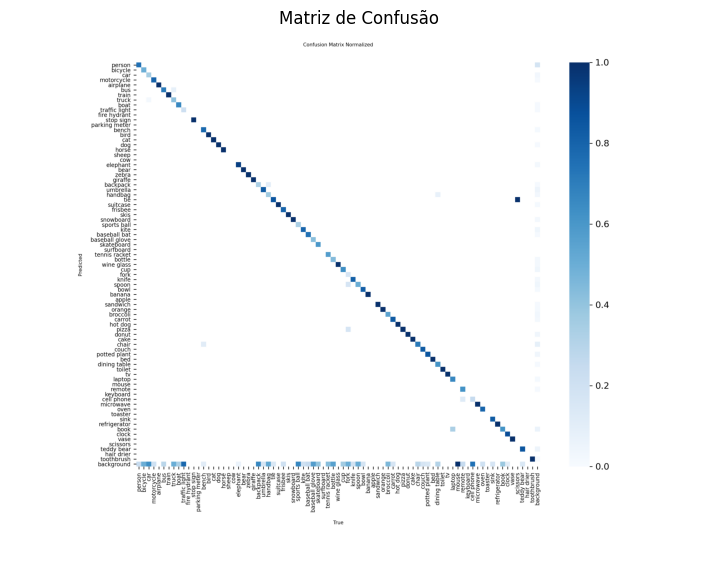

✅ Matriz de confusão carregada de: /content/runs/detect/val/confusion_matrix_normalized.png


In [9]:
import glob as _glob

def exibir_matriz_confusao(metrics_obj):
    """Localiza o confusion_matrix.png gerado pelo val() e o exibe. Se não achar,
    plota manualmente a partir de metrics_obj.confusion_matrix."""
    # 1) Tenta achar o PNG gerado automaticamente pela Ultralytics
    save_dir = getattr(metrics_obj, "save_dir", None)
    candidatos = []
    if save_dir is not None:
        candidatos += _glob.glob(os.path.join(str(save_dir), "confusion_matrix_normalized.png"))
        candidatos += _glob.glob(os.path.join(str(save_dir), "confusion_matrix.png"))

    if candidatos:
        img = cv2.cvtColor(cv2.imread(candidatos[0]), cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(9, 8))
        plt.imshow(img)
        plt.axis("off")
        plt.title("Matriz de Confusão")
        plt.show()
        print(f"✅ Matriz de confusão carregada de: {candidatos[0]}")
        return

    # 2) Fallback: plot manual a partir dos dados de metrics.confusion_matrix
    print("⚠️ PNG da matriz de confusão não encontrado — plotando manualmente a partir dos dados.")
    cm = metrics_obj.confusion_matrix.matrix  # shape (n_classes+1, n_classes+1) — última linha/col = background
    nomes = [NAMES_PT.get(i, n) for i, n in metrics_obj.names.items()] + ["background"]

    plt.figure(figsize=(9, 8))
    plt.imshow(cm, cmap="Blues")
    plt.colorbar(label="Nº de predições")
    plt.xticks(range(len(nomes)), nomes, rotation=90, fontsize=7)
    plt.yticks(range(len(nomes)), nomes, fontsize=7)
    plt.xlabel("Classe verdadeira")
    plt.ylabel("Classe prevista")
    plt.title("Matriz de Confusão (reconstruída)")
    plt.tight_layout()
    plt.show()


try:
    exibir_matriz_confusao(metrics)
except Exception as e:
    print(f"⚠️ Não foi possível gerar a matriz de confusão: {e}")


## 7. Inferência em imagens de teste + visualização das detecções

Selecionamos algumas imagens (do split de validação do dataset já presente dentro do
Colab, ou você pode apontar para suas próprias imagens enviadas para `/content`) e
exibimos as detecções com bounding boxes, labels e confiança sobrepostos, como prova
visual de que o modelo está funcionando.


In [10]:
def coletar_imagens_teste(dataset_yaml, n=8):
    """Coleta até n imagens do split de validação do dataset (dentro do Colab) para teste."""
    possible_roots = [
        Path("/content/datasets") / dataset_yaml.replace(".yaml", ""),
        Path("datasets") / dataset_yaml.replace(".yaml", ""),
    ]
    imgs = []
    for root in possible_roots:
        if root.exists():
            imgs = list(root.rglob("*.jpg")) + list(root.rglob("*.png"))
            if imgs:
                break

    if not imgs:
        print("⚠️ Não foi possível localizar imagens automaticamente. "
              "Defina TEST_IMAGES manualmente com caminhos dentro de /content.")
        return []

    random.seed(42)
    amostra = random.sample(imgs, min(n, len(imgs)))
    return [str(p) for p in amostra]


TEST_IMAGES = coletar_imagens_teste(DATASET_YAML, n=8)

# Caso a busca automática falhe (ex: dataset customizado com outra estrutura),
# defina manualmente a lista de imagens de teste aqui (envie as imagens para /content antes):
# TEST_IMAGES = ["/content/minhas_imagens/img1.jpg", "/content/minhas_imagens/img2.jpg"]

print(f"🖼️ {len(TEST_IMAGES)} imagens de teste selecionadas.")
assert len(TEST_IMAGES) > 0, "Nenhuma imagem de teste disponível — defina TEST_IMAGES manualmente."


🖼️ 8 imagens de teste selecionadas.


In [11]:
print("🔎 Executando inferências...")

pred_results = best_model.predict(
    source=TEST_IMAGES,
    imgsz=IMG_SIZE,
    conf=0.25,      # limiar mínimo de confiança
    save=False,
    verbose=False,
)

print(f"✅ Inferência concluída em {len(pred_results)} imagens.")


🔎 Executando inferências...
✅ Inferência concluída em 8 imagens.


In [12]:
# Visualiza as detecções (bounding boxes + labels em português + confiança) em grade
n_imgs = len(pred_results)
cols = min(3, n_imgs)
rows = (n_imgs + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
axes = np.array(axes).reshape(-1) if n_imgs > 1 else [axes]

for i, r in enumerate(pred_results):
    r.names = NAMES_PT  # troca os labels em inglês pelos traduzidos antes de desenhar
    annotated = r.plot()  # imagem BGR com boxes, labels (em português) e confiança desenhados
    annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

    n_det = len(r.boxes)
    axes[i].imshow(annotated_rgb)
    axes[i].set_title(f"Imagem {i+1} — {n_det} objeto(s) detectado(s)", fontsize=10)
    axes[i].axis("off")

# Esconde eixos extras não usados na grade
for j in range(n_imgs, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

print("✅ Visualizações exibidas acima — prova visual das detecções do modelo.")


Output hidden; open in https://colab.research.google.com to view.

In [13]:
# Resumo textual das detecções por imagem (classe em português + confiança)
for i, r in enumerate(pred_results):
    nomes = NAMES_PT
    print(f"\nImagem {i+1}: {Path(TEST_IMAGES[i]).name}")
    if len(r.boxes) == 0:
        print("   Nenhum objeto detectado acima do limiar de confiança.")
        continue
    for box in r.boxes:
        cls_id = int(box.cls[0])
        conf = float(box.conf[0])
        print(f"   - {nomes[cls_id]}: {conf:.2%} de confiança")



Imagem 1: 000000000294.jpg
   - relógio: 96.76% de confiança
   - pessoa: 94.38% de confiança
   - micro-ondas: 85.00% de confiança
   - faca: 65.72% de confiança
   - faca: 55.93% de confiança
   - colher: 55.53% de confiança
   - faca: 55.22% de confiança
   - faca: 49.96% de confiança
   - faca: 42.79% de confiança
   - geladeira: 42.24% de confiança
   - colher: 39.23% de confiança
   - relógio: 39.02% de confiança
   - micro-ondas: 38.67% de confiança
   - colher: 34.21% de confiança
   - colher: 31.61% de confiança
   - faca: 31.40% de confiança
   - colher: 31.19% de confiança
   - colher: 31.08% de confiança
   - faca: 28.19% de confiança
   - colher: 27.58% de confiança
   - colher: 26.03% de confiança
   - colher: 25.09% de confiança

Imagem 2: 000000000326.jpg
   - taça de vinho: 98.24% de confiança
   - pessoa: 84.32% de confiança

Imagem 3: 000000000564.jpg
   - pessoa: 92.52% de confiança
   - cadeira: 76.57% de confiança
   - cadeira: 76.48% de confiança
   - pessoa: 74

## 8. Exportação do modelo para ONNX

Exportamos os melhores pesos (`best.pt`) para o formato ONNX, já com simplificação do
grafo (`simplify=True`) para reduzir overhead em produção, e opset compatível com a
maioria dos runtimes (ONNX Runtime, TensorRT, OpenVINO, etc.). O arquivo é gerado dentro
do Colab, ao lado dos pesos `.pt`.


In [14]:
print("📦 Exportando modelo para ONNX...")

try:
    onnx_path = best_model.export(
        format="onnx",
        imgsz=IMG_SIZE,
        opset=12,          # boa compatibilidade com a maioria dos runtimes
        simplify=True,     # simplifica o grafo ONNX (menor e mais rápido)
        dynamic=False,     # shape fixo = melhor performance; use True se precisar de batch/tamanho variável
    )
    print(f"✅ Modelo exportado para: {onnx_path}")
except Exception as e:
    print(f"❌ Erro ao exportar para ONNX: {e}")
    raise


📦 Exportando modelo para ONNX...
Ultralytics 8.4.160 🚀 Python-3.13.15 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino
Model summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs

PyTorch: starting from '/content/runs_yolo/treino_yolov8/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 84, 8400) (6.2 MB)
requirements: Ultralytics requirement ['onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.13.15 environment at: /usr
Resolved 10 packages in 412ms
Prepared 2 packages in 41ms
Installed 2 packages in 9ms
 + colorama==0.4.6
 + onnxslim==0.1.96

requirements: AutoUpdate success ✅ 0.9s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.23.0 opset 12...
ONNX: slimming with onnxslim 0.1.96...
ONNX: export success ✅

## 9. Embutir nomes traduzidos no ONNX, confirmar e copiar para pasta de saída

A Ultralytics grava os nomes das classes dentro do próprio arquivo `.onnx`, como metadado
(`metadata_props["names"]`) — é isso que ferramentas como Netron mostram, e é o que sua
aplicação pode ler via `onnxruntime` (`session.get_modelmeta().custom_metadata_map`) para
não precisar reescrever a lista de classes na mão. Por padrão essa metadata sai em inglês.

Nesta célula:

1. Validamos a estrutura do ONNX com `onnx.checker`.
2. **Substituímos essa metadata pelos nomes em português (`NAMES_PT`)** e resalvamos o
   arquivo — assim, o `.onnx` que você for baixar e usar na sua aplicação já carrega os
   nomes traduzidos embutidos nele.
3. Testamos com `onnxruntime` (fora do ambiente Ultralytics) e conferimos que a metadata
   lida de volta já vem em português.
4. Copiamos o arquivo final para `OUTPUT_DIR`, pronto para download manual pela aba
   **Arquivos** do Colab.

⚠️ Importante para sua aplicação: o modelo ONNX em si (as camadas de rede) sempre gera
como saída **IDs numéricos de classe** + caixas + confiança — isso não muda. O que muda é
que o nome em português de cada ID agora está embutido no arquivo, então sua aplicação só
precisa ler essa metadata (em vez de manter uma tabela de tradução separada) para exibir
os labels certos.


In [15]:
import onnx
import onnxruntime as ort
import shutil
import ast

# 1) Validação estrutural do grafo ONNX
try:
    onnx_model = onnx.load(onnx_path)
    onnx.checker.check_model(onnx_model)
    print("✅ Arquivo ONNX é válido (passou no onnx.checker).")
except Exception as e:
    print(f"❌ Modelo ONNX inválido: {e}")
    raise

# 2) Substitui a metadata 'names' (classes) do ONNX pelas traduções em português
def embutir_nomes_traduzidos(modelo_onnx, names_pt):
    """Sobrescreve (ou cria) a entrada metadata_props['names'] do grafo ONNX com as
    traduções em português, no mesmo formato de repr de dict usado pela Ultralytics —
    assim qualquer app que já sabe ler essa metadata continua funcionando, só que
    recebendo os nomes em português."""
    nomes_str = str(names_pt)  # ex: "{0: 'pessoa', 1: 'bicicleta', ...}"
    for prop in modelo_onnx.metadata_props:
        if prop.key == "names":
            prop.value = nomes_str
            return modelo_onnx, True
    novo_prop = modelo_onnx.metadata_props.add()
    novo_prop.key = "names"
    novo_prop.value = nomes_str
    return modelo_onnx, False

onnx_model, ja_existia = embutir_nomes_traduzidos(onnx_model, NAMES_PT)
onnx.checker.check_model(onnx_model)  # revalida depois da alteração
onnx.save(onnx_model, onnx_path)      # resalva o .onnx já com a metadata traduzida
acao = "atualizada" if ja_existia else "criada"
print(f"✅ Metadata 'names' {acao} no ONNX com as classes em português.")

# 3) Teste de inferência com onnxruntime (simula o uso em produção, fora da Ultralytics)
try:
    session = ort.InferenceSession(onnx_path, providers=["CPUExecutionProvider"])
    input_name = session.get_inputs()[0].name
    input_shape = session.get_inputs()[0].shape
    print(f"✅ ONNX Runtime carregou o modelo. Input: '{input_name}' shape={input_shape}")

    dummy_input = np.random.rand(1, 3, IMG_SIZE, IMG_SIZE).astype(np.float32)
    outputs = session.run(None, {input_name: dummy_input})
    print(f"✅ Inferência de teste (entrada aleatória) executada com sucesso. "
          f"Formato da saída: {outputs[0].shape}")

    # Confirma que a metadata lida de volta do arquivo já está em português
    meta = session.get_modelmeta().custom_metadata_map
    if "names" in meta:
        nomes_no_arquivo = ast.literal_eval(meta["names"])
        print("\n📋 Classes lidas de volta do .onnx (confirmação):")
        for idx in sorted(nomes_no_arquivo.keys()):
            print(f"   {idx}: {nomes_no_arquivo[idx]}")
    else:
        print("⚠️ Metadata 'names' não encontrada ao reler o arquivo — verifique o passo 2 acima.")
except Exception as e:
    print(f"❌ Erro ao rodar inferência de teste com onnxruntime: {e}")
    raise

# 4) Copia o arquivo final (já com metadata traduzida) para a pasta de saída, dentro do Colab
final_name = f"{RUN_NAME}_{Path(MODEL_NAME).stem}.onnx"
final_path = os.path.join(OUTPUT_DIR, final_name)
shutil.copy(onnx_path, final_path)

file_size_mb = os.path.getsize(final_path) / (1024 * 1024)
print(f"\n📦 Resumo final:")
print(f"   Arquivo: {final_name}")
print(f"   Tamanho: {file_size_mb:.2f} MB")
print(f"   Local:   {final_path}")
print(f"   Classes: embutidas em português na metadata 'names' do próprio arquivo")


✅ Arquivo ONNX é válido (passou no onnx.checker).
✅ Metadata 'names' atualizada no ONNX com as classes em português.
✅ ONNX Runtime carregou o modelo. Input: 'images' shape=[1, 3, 640, 640]
✅ Inferência de teste (entrada aleatória) executada com sucesso. Formato da saída: (1, 84, 8400)

📋 Classes lidas de volta do .onnx (confirmação):
   0: pessoa
   1: bicicleta
   2: carro
   3: moto
   4: avião
   5: ônibus
   6: trem
   7: caminhão
   8: barco
   9: semáforo
   10: hidrante
   11: placa de pare
   12: parquímetro
   13: banco
   14: pássaro
   15: gato
   16: cachorro
   17: cavalo
   18: ovelha
   19: vaca
   20: elefante
   21: urso
   22: zebra
   23: girafa
   24: mochila
   25: guarda-chuva
   26: bolsa
   27: gravata
   28: mala
   29: frisbee
   30: esquis
   31: snowboard
   32: bola esportiva
   33: pipa
   34: taco de beisebol
   35: luva de beisebol
   36: skate
   37: prancha de surfe
   38: raquete de tênis
   39: garrafa
   40: taça de vinho
   41: xícara
   42: garfo

## 10. Como baixar o arquivo manualmente

Não é necessário rodar mais nenhuma célula. No painel lateral esquerdo do Colab:

1. Clique no ícone de pasta 📁 (**Arquivos**).
2. Navegue até `output_model/`.
3. Clique com o botão direito no arquivo `.onnx` gerado → **Fazer download**.

Lembre-se: como o armazenamento do Colab é temporário, baixe o arquivo antes de encerrar
ou deixar a sessão expirar — depois disso ele é apagado e será preciso rodar o notebook
novamente.
